## Welfare Bot - Linear Regression Analysis

Tässä notebookissa käytän lineaarista regressiota ennustamaan käyttäjän kokonaisvaltaista hyvinvointia (`overall_score`).

Tavoitteena on analysoida, miten eri hyvinvointimittarit vaikuttavat käyttäjän kokonaisvaltaiseen hyvinvointiin.

In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split # data splitataan koulutus- ja testijoukkoihin, jotta voidaan 
                                                     # arvioida mallin suorituskykyä
from sklearn.linear_model import LinearRegression    # lineaarinen regressio on yksinkertainen malli, joka sopii hyvin tähän dataan, 
                                                     # koska haluamme ymmärtää, miten eri tekijät vaikuttavat kokonaisvaltaiseen hyvinvointiin
from sklearn.metrics import mean_absolute_error, r2_score  # Mean Absolute Error (MAE) mittaa mallin ennusteiden keskimääräistä poikkeamaa 
                                                     # todellisista arvoista, ja R² kertoo, kuinka hyvin malli selittää datan vaihtelua

In [34]:
data = pd.read_csv("../data/welfare_bot_metrics_cleaned.csv") # luetaan data CSV-tiedostosta pandas DataFrameen, 
                                                              #  jotta voimme analysoida ja visualisoida sitä

data.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
0,2025-01-01,Aino Mäkinen,aino.makinen@demo.fi,4.40,3.94,2.99,1.00,0.88,3.38,8.890,low
1,2025-01-02,Aino Mäkinen,aino.makinen@demo.fi,4.83,4.31,2.66,0.96,0.86,3.27,8.980,low
2,2025-01-03,Aino Mäkinen,aino.makinen@demo.fi,4.30,3.24,2.28,0.80,0.82,3.66,7.670,low
3,2025-01-04,Aino Mäkinen,aino.makinen@demo.fi,3.84,3.44,3.00,0.79,0.91,2.79,7.765,NaN
4,2025-01-05,Aino Mäkinen,aino.makinen@demo.fi,3.99,4.05,2.46,0.94,0.85,3.36,8.250,low


## Missing values handling

Ennen mallin kouluttamista tarkistan ja poistan rivit, joissa puuttuu arvoja.

Puuttuvat arvot voivat aiheuttaa virheitä lineaarisessa regressiomallissa, koska malli ei pysty käsittelemään NaN-arvoja suoraan.

Tässä vaiheessa käytän cleaned-datasettiä, jossa tärkeimmät puuttuvat arvot on jo käsitelty preprocessing-vaiheessa.

In [52]:
data = data.dropna()

## Feature selection

Valitsin hyvinvointimittarit selittäviksi muuttujiksi, koska niiden oletetaan vaikuttavan käyttäjän kokonaisvaltaiseen hyvinvointiin.

In [35]:
features = [
    "mood_score",
    "sleep_score",
    "food_score",
    "hydration_score",
    "medication_score",
    "social_score"
]

X = data[features]

y = data["overall_score"]

## Datan jakaminen

Jaan datan training- ja testidataan, jotta voin arvioida mallin suorituskykyä uudella datalla.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20% datasta testijoukkoon, jotta voimme arvioida mallin suorituskykyä uudella datalla, jota malli ei ole nähnyt koulutuksen aikana
    random_state=42 # asetetaan random_state, jotta data splitataan samaan tapaan joka kerta, mikä tekee tuloksista vertailukelpoisia
)

## Train model

Tässä vaiheessa luon lineaarisen regressiomallin ja koulutan sen training-datalla.

Lineaarinen regressio yrittää löytää yhteyden hyvinvointimittareiden ja kokonaisvaltaisen hyvinvoinnin ('overall_score') välillä.

Mallin tavoitteena on oppia, miten eri hyvinvointitekijät yhdessä vaikuttavat käyttäjän vointiin.

Koulutuksen aikana algoritmi analysoi training-datan arvoja ja laskee jokaiselle featurelle painokertoimen.

Tämän jälkeen mallia voidaan käyttää uusien hyvinvointiarvojen ennustamiseen.

In [37]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predictions

Tässä vaiheessa käytän koulutettua mallia ennustamaan testidatan 'overall_score'-arvoja.

Mallille annetaan hyvinvointimittarit ('mood_score', 'sleep_score', 'food_score' jne.), ja se yrittää ennustaa käyttäjän kokonaisvaltaisen hyvinvointiskoorin niiden perusteella.

Ennusteita verrataan myöhemmin todellisiin arvoihin, jotta voidaan arvioida mallin tarkkuutta.

In [38]:
predictions = model.predict(X_test)

## Evaluation

Tässä vaiheessa arvioin mallin suorituskykyä.

Käytän kahta arviointimittaria:

- MAE (Mean Absolute Error)
- R² score

MAE kertoo, kuinka paljon mallin ennusteet poikkeavat keskimäärin todellisista arvoista.

Mitä pienempi MAE-arvo on, sitä tarkempia ennusteet ovat.

R² score kertoo, kuinka hyvin malli pystyy selittämään datan vaihtelua.

Arvo lähellä yhtä tarkoittaa, että malli ymmärtää hyvin hyvinvointimittareiden ja 'overall_score'-arvon välisiä yhteyksiä.

In [45]:
mae = mean_absolute_error(y_test, predictions) # MAE mittaa mallin ennusteiden keskimääräistä poikkeamaa todellisista 
                                               # arvoista, ja pienempi MAE tarkoittaa parempaa mallia

r2 = r2_score(y_test, predictions) # R² kertoo, kuinka hyvin malli selittää datan vaihtelua, ja se on välillä 0-1,
                                   # jossa 1 tarkoittaa täydellistä selitystä ja 0 tarkoittaa, että malli ei selitä 
                                   # lainkaan datan vaihtelua

print("MAE:", mae)

print("R2 score:", r2)

MAE: 0.36867300436545575
R2 score: 0.5250472157528792


## Mallin arviointi

MAE kertoo keskimääräisen ennustevirheen.

R2 score kertoo, kuinka hyvin malli pystyy selittämään kokonaisvaltaisen hyvinvoinnin vaihtelua.

## Feature importance

Tässä vaiheessa tarkastelen, mitkä hyvinvointimittarit vaikuttavat eniten overall_score-arvoon.

Lineaarinen regressiomalli oppii jokaiselle featurelle kertoimen (coefficient), joka kuvaa vaikutuksen voimakkuutta.

Suurempi positiivinen arvo tarkoittaa voimakkaampaa positiivista vaikutusta kokonaisvaltaiseen hyvinvointiin.

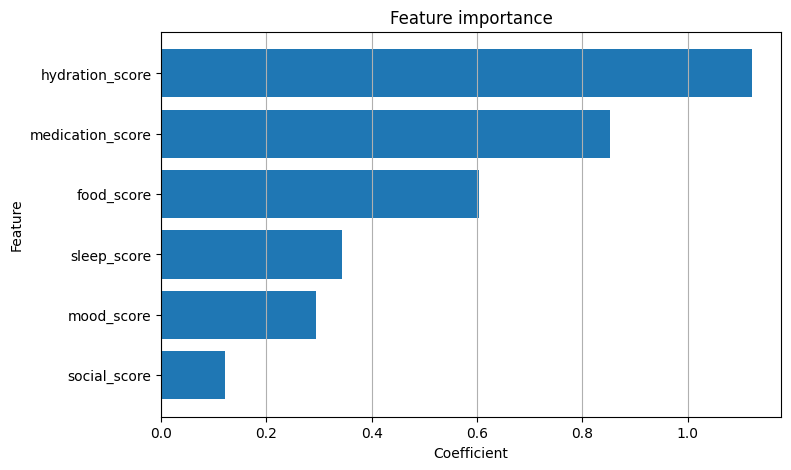

In [50]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

importance = importance.sort_values("Coefficient", ascending=True)
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Coefficient"]
)

plt.title("Feature importance")

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.grid(axis="x")

plt.show()

## Feature importance analysointi

Visualisoinnin perusteella hydration_score vaikutti voimakkaimmin käyttäjän kokonaisvaltaiseen hyvinvointiin.

Myös medication_score ja food_score näyttivät olevan merkittäviä hyvinvointiin vaikuttavia tekijöitä.

Tulokset viittaavat siihen, että erityisesti perustarpeet, kuten nesteytys, lääkitys ja ravinto, ovat tärkeässä roolissa käyttäjän hyvinvoinnin ylläpitämisessä.

Sleep_score ja mood_score vaikuttivat myös hyvinvointiin, mutta hieman vähemmän tässä analyysissä.

Social_score sai pienimmän kertoimen tässä mallissa. Tämä ei kuitenkaan tarkoita, ettei sosiaalisella aktiivisuudella olisi vaikutusta hyvinvointiin. Sosiaalisten kontaktien vaikutukset voivat näkyä pidemmällä aikavälillä ja epäsuoremmin kuin fyysiset perustarpeet.

## Visualization

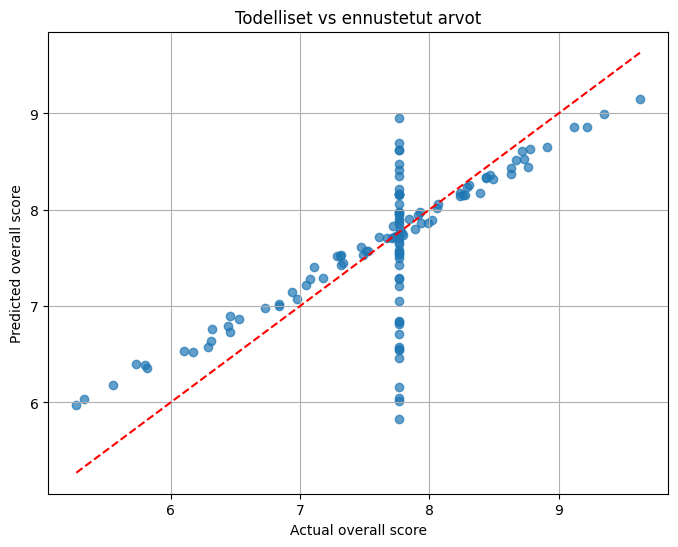

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual overall score")
plt.ylabel("Predicted overall score")

plt.title("Todelliset vs ennustetut arvot")

plt.grid()

plt.show()

## Visualisoinnin analysointi

Visualisoinnissa verrataan mallin ennustamia arvoja todellisiin 'overall_score'arvoihin.

Jos pisteet sijoittuvat lähelle diagonaalista linjaa, malli ennustaa hyvin.

Mitä kauempana pisteet ovat toisistaan, sitä suurempi ennustevirhe mallilla on.

Visualisointi auttaa ymmärtämään mallin tarkkuutta käytännössä ja näyttää, kuinka hyvin lineaarinen regressio soveltui hyvinvointidatan analysointiin.

## Residual analysis

Residual tarkoittaa mallin ennusteen ja todellisen arvon välistä erotusta.

Tämän visualisoinnin avulla voidaan tarkastella:

- missä tilanteissa malli tekee suurimpia virheitä
- ovatko virheet satunnaisia
- toimiiko malli tasaisesti eri hyvinvointitasoilla

Suuret poikkeamat voivat viitata tilanteisiin, joissa käyttäjän hyvinvointiin vaikuttaa myös muita tekijöitä, joita mallissa ei huomioitu.

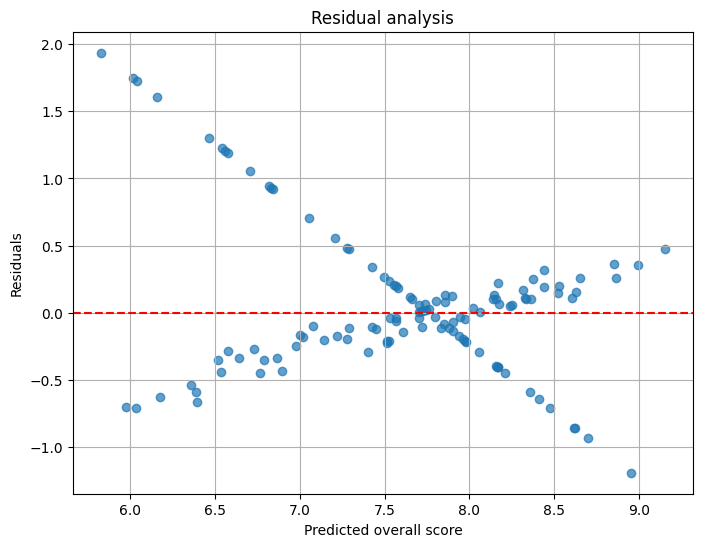

In [48]:
# Lasketaan residuals
residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted overall score")
plt.ylabel("Residuals")

plt.title("Residual analysis")

plt.grid()

plt.show()

## Residual analysis interpretation

Tässä visualisoinnissa tarkastelen, kuinka paljon lineaarisen regressiomallin ennusteet poikkesivat todellisista overall_score-arvoista.

Punainen katkoviiva kuvaa kohtaa, jossa ennuste vastaa täysin todellista arvoa.

Visualisoinnissa näkyy, että suurin osa residual-arvoista sijoittuu melko lähelle nollaviivaa, mikä tarkoittaa, että malli pystyi ennustamaan käyttäjän hyvinvoinnin suhteellisen hyvin.

Datassa näkyy kuitenkin myös suurempia poikkeamia erityisesti erittäin matalissa ja korkeissa hyvinvointiarvoissa. Tämä viittaa siihen, että käyttäjän kokonaisvaltainen hyvinvointi ei riipu täysin lineaarisesti vain valituista featureista.

Tulokset osoittavat, että lineaarinen regressio soveltui hyvin yksinkertaiseen hyvinvointidatan analysointiin.

Mallilla oli kuitenkin myös rajoituksia, ja osa hyvinvoinnin vaihtelusta jäi selittämättä.

## Residual distribution

Tässä visualisoin residual-arvojen jakauman.

Histogrammi auttaa ymmärtämään:

- kuinka suuria mallin virheet yleensä ovat
- esiintyykö datassa paljon suuria ennustevirheitä
- ovatko virheet jakautuneet tasaisesti

Jos suurin osa residualeista sijoittuu lähelle nollaa, malli toimii yleensä hyvin.


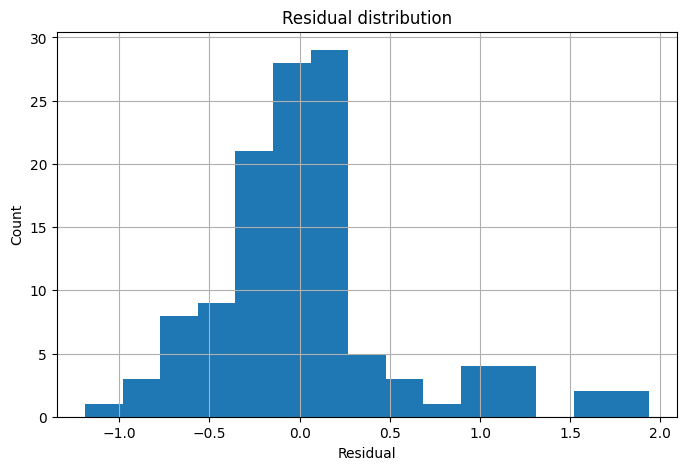

In [49]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=15
)

plt.title("Residual distribution")

plt.xlabel("Residual")
plt.ylabel("Count")

plt.grid()

plt.show()

## Residual distribution interpretation

Histogrammista näkyy, että suurin osa residual-arvoista sijoittuu melko lähelle nollaa. Tämä tarkoittaa, että mallin ennusteet olivat useimmiten suhteellisen lähellä todellisia overall_score-arvoja.

Datassa näkyy kuitenkin myös joitakin suurempia positiivisia ja negatiivisia residual-arvoja. Tämä kertoo, että malli ei pystynyt ennustamaan kaikkia hyvinvointitilanteita täysin tarkasti.

Tulokset ovat kuitenkin realistisia hyvinvointidatan analysoinnissa, koska käyttäjän kokonaisvaltaiseen hyvinvointiin vaikuttaa usein myös muita tekijöitä, joita tässä mallissa ei huomioitu.

Visualisointi auttaa ymmärtämään mallin virheiden jakaumaa ja arvioimaan, kuinka luotettavasti lineaarinen regressiomalli soveltui hyvinvointidatan ennustamiseen.

## Sosiaalisen aktiivisuuden vaikutus tulevaan hyvinvointiin

Tässä vaiheessa tarkastelen hypoteesia:

voiko sosiaalisen aktiivisuuden väheneminen liittyä käyttäjän tulevaan hyvinvoinnin heikkenemiseen.

Tavoitteena on analysoida, näkyykö social_score-arvon ja tulevan overall_score-arvon välillä yhteyttä.

In [ ]:
# Shiftataan overall_score yhdellä päivällä eteenpäin,
# jotta voidaan tarkastella seuraavan päivän hyvinvointia
data["future_overall_score"] = data["overall_score"].shift(-1)

# Poistetaan rivit, joissa future_overall_score puuttuu
future_data = data.dropna(subset=["future_overall_score"])

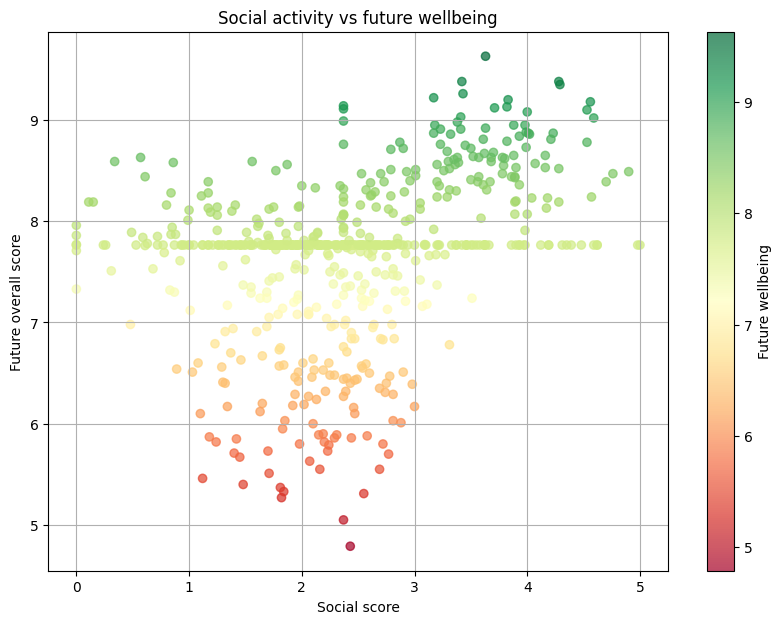

In [51]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    future_data["social_score"],
    future_data["future_overall_score"],
    c=future_data["future_overall_score"],
    cmap="RdYlGn",
    alpha=0.7
)

plt.colorbar(scatter, label="Future wellbeing")

plt.title("Social activity vs future wellbeing")

plt.xlabel("Social score")
plt.ylabel("Future overall score")

plt.grid()

plt.show()

Visualisoinnin perusteella korkeampi social_score näyttää usein liittyvän parempaan tulevaan hyvinvointiin.

Vaikka yhteys ei ole täysin suora, datassa näkyy trendi, jossa sosiaalisesti aktiivisemmilla käyttäjillä future_overall_score oli useammin korkeampi.

Tämä tukee Welfare Bot -projektin ideaa siitä, että sosiaalinen vuorovaikutus voi olla tärkeä osa käyttäjän hyvinvointia ja mahdollinen varhainen signaali hyvinvoinnin muutoksista.